In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
df = pd.read_csv("House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [22]:
# Task 1 Identify data quality issues in the dataset

In [23]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.dtypes

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64
0


Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

In [24]:
# missing values: 0
# duplicate rows: 0
# data types: Correct, numerical and categorical separated
# no issues

In [25]:
# Task 2 Apply one missing value strategy and explain why

In [26]:
# strategy 1 is not suitable because removing records is ineffective. 
# strategy 2 is not suitable because its sensitive to outliers. 
# so we will use strategy 3 median imputation. (here we dont have missing values but we apply the strategy regardless)

In [27]:
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

In [28]:
# Task 3 Detect and handle outliers using IQR

In [29]:
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [30]:
# no outliers detected

In [31]:
# Task 4 Normalize numerical features using both Min-Max and Z-score

In [32]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
df_mm = mm.fit_transform(df.select_dtypes(include='number'))

In [33]:
from sklearn.preprocessing import StandardScaler

z = StandardScaler()
df_z = z.fit_transform(df.select_dtypes(include='number'))

In [34]:
# Task 5 Apply PCA only if the numerical features show a correlation

In [35]:
corr = df.select_dtypes(include='number').corr()
corr

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


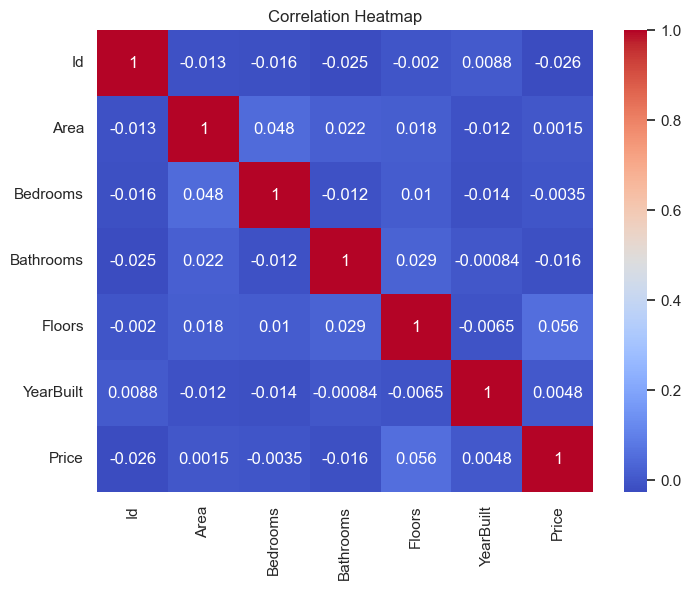

In [36]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [37]:
# no correlation. cannot apply PCA